# 3주차 Netflix 데이터 분석 실습

이번 실습에서는 `netflix_titles.csv` 데이터를 사용하여 실제 데이터 분석 과정을 공부한다.  
데이터 구조를 확인하고, 결측값(NaN)을 이해하고 처리한 뒤, 분포 분석, 조건 필터링, 그룹핑, 시각화 등을 수행한다.

## 3주차 학습 목표

1. `netflix_titles.csv` 데이터를 불러올 수 있다.  
   - `pd.read_csv()`를 사용하여 CSV 파일을 데이터프레임으로 읽는다.

2. 데이터프레임의 구조를 탐색할 수 있다.  
   - `info()`를 사용하여 데이터 타입과 결측값 여부 등을 확인한다.  
   - `head()`를 사용하여 데이터의 앞부분을 확인한다.     
   - `columns`를 사용하여 컬럼 이름을 확인한다.

3. NaN의 의미를 이해할 수 있다.  
   - NaN은 비어 있는 값 또는 결측값을 의미함 
   - 어떤 컬럼에 결측값이 있는지 확인할 수 있다.

4. 결측값(NaN)을 확인하고 처리할 수 있다.  
   - `isnull().sum()`을 사용하여 결측값 개수를 확인한다.  
   - `dropna()`를 사용하여 결측값을 제거할 수 있다.  
   - `fillna()`를 사용하여 결측값을 다른 값으로 채울 수 있다.

5. `value_counts()`를 사용하여 범주형 데이터의 분포를 분석할 수 있다.  
   - 콘텐츠 유형, 국가, 시청 등급 등의 등장 횟수를 계산한다.

6. `plot()`을 사용하여 데이터 분포를 시각화할 수 있다.  
   - `value_counts().plot()`를 사용하여 값의 등장 횟수를 시각화

7. matplotlib.pyplot을 사용하여 그래프를 설정할 수 있다.  
   - `plt.title()`을 사용하여 그래프 제목을 설정한다.  
   - `plt.xlabel()`과 `plt.ylabel()`를 사용하여 축 이름을 설정한다.  
   - `plt.xticks()`를 사용하여 축 글자를 회전할 수 있다.  
   - `plt.show()`를 사용하여 그래프를 화면에 출력한다.

8. 조건 필터링을 사용하여 원하는 데이터를 선택할 수 있다.  
   - 비교 연산자를 사용하여 데이터를 필터링한다.  
   - 여러 조건을 `&`, `|`로 결합할 수 있다. 이때 각 조건은 (  ) 로 묶어 구분한다.

9. `groupby()`를 사용하여 데이터를 그룹별로 분석할 수 있다.  
   - 특정 기준으로 데이터를 그룹화할 수 있다.  
   - 그룹별 개수, 평균 등의 통계값을 계산할 수 있다.

10. 분석 결과를 해석하여 데이터의 특징을 설명할 수 있다.  
   - Netflix 데이터에서 콘텐츠 유형, 국가, 연도 분포에 대해 설명할 수 있다.


## 사용할 데이터셋

이번 시간에는 Kaggle의 Netflix 데이터셋 파일인 `netflix_titles.csv`를 사용

- `type` : 콘텐츠 유형 (`Movie`, `TV Show`)
- `title` : 제목
- `director` : 감독
- `cast` : 출연진
- `country` : 제작 국가
- `date_added` : Netflix에 추가된 날짜
- `release_year` : 공개 연도
- `rating` : 시청 등급
- `duration` : 상영 시간 또는 시즌 수
- `listed_in` : 장르
- `description` : 콘텐츠의 간단한 줄거리 또는 소개 글

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

In [5]:
df = pd.read_csv('netflix_titles.csv')
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


## 데이터 구조 확인

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


## NaN이란 무엇인가?

- 데이터를 분석하다 보면 값이 비어 있는 경우가 많아요.pandas에서는 이러한 값을 **NaN**으로 표시
- NaN은 **결측값**, 즉 비어 있는 값으로 이해하면 된다.

## NaN 확인과 처리

결측값은 분석 결과에 영향을 줄 수 있으므로 먼저 확인해야 한다.

대표적인 방법은 다음과 같다.

- `isnull().sum()` : 컬럼별 결측값 개수 확인  
- `dropna()` : 결측값이 있는 행 제거  
- `fillna()` : 결측값을 다른 값으로 대체


df.isnull().sum()

위의 코드를 아래 셀에 쓰고 실행하세요

In [9]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [10]:
df.dropna()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...
24,s25,Movie,Jeans,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,"September 21, 2021",1998,TV-14,166 min,"Comedies, International Movies, Romantic Movies",When the father of the man she loves insists t...
...,...,...,...,...,...,...,...,...,...,...,...,...
8801,s8802,Movie,Zinzana,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...","United Arab Emirates, Jordan","March 9, 2016",2015,TV-MA,96 min,"Dramas, International Movies, Thrillers",Recovering alcoholic Talal wakes up inside a s...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [ ]:
# df.dropna()     
# df['rating'] = df['rating'].dropna()

### NaN 값이 있는 열들의 데이터 형식을 보면 모두 object 또는 str 즉 문자열 이므로 'missing'으로 채워보세요

df = df.fillna('missing')   
df

In [11]:
df = df.fillna('missing')
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,missing,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,missing,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",missing,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,missing,missing,missing,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,missing,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,missing,missing,missing,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


## 범주형 데이터 분포 분석

`value_counts()`는 각 값이 몇 번 등장하는지 계산한다.


In [12]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,missing,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,missing,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",missing,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,missing,missing,missing,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,missing,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [13]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [14]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [17]:
df['country'].value_counts().head(10)

country
United States     2818
India              972
missing            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

In [18]:
df['rating'].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
missing        4
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [20]:
df['release_year'].value_counts(10)

release_year
2018    0.130237
2017    0.117180
2019    0.116952
2020    0.108209
2016    0.102419
          ...   
1959    0.000114
1925    0.000114
1961    0.000114
1947    0.000114
1966    0.000114
Name: proportion, Length: 74, dtype: float64

## 시각화

`plot()`을 사용하면 분포를 그래프로 표현할 수 있다.


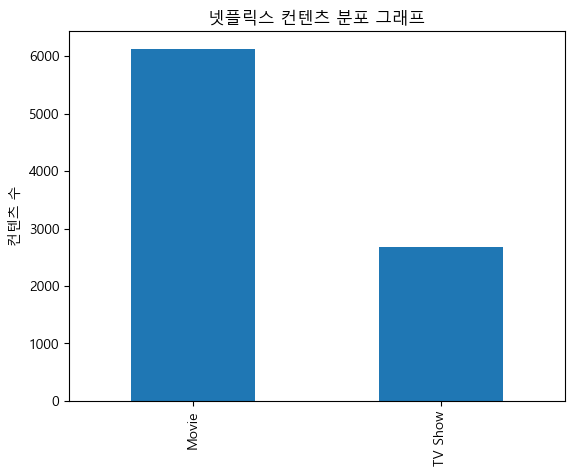

In [25]:
df['type'].value_counts().plot(kind='bar')
plt.title('넷플릭스 컨텐츠 분포 그래프')
plt.xlabel('')
plt.ylabel('컨텐츠 수')
plt.show()

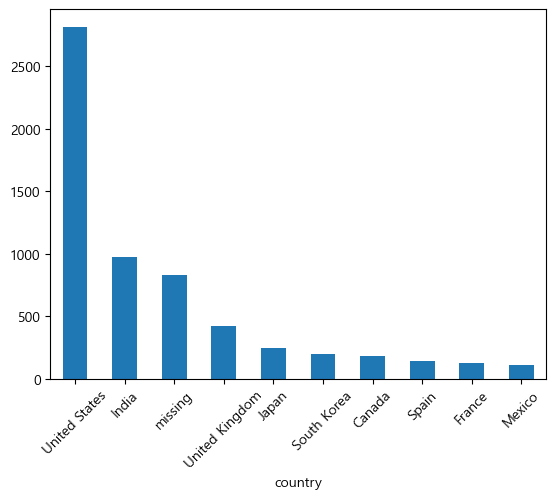

In [29]:
df['country'].value_counts().head(10).plot.bar()
plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='rating'>

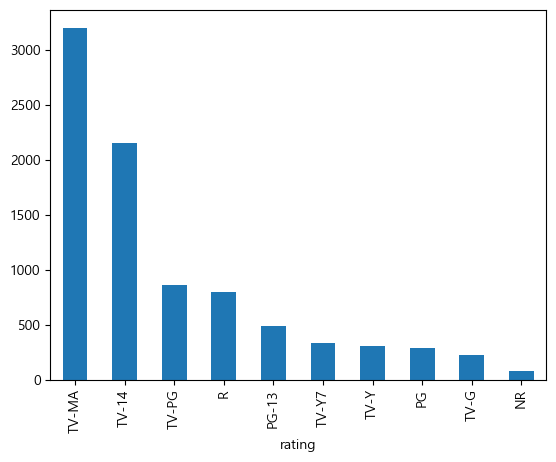

In [31]:
df['rating'].value_counts().head(10).plot(kind='bar')

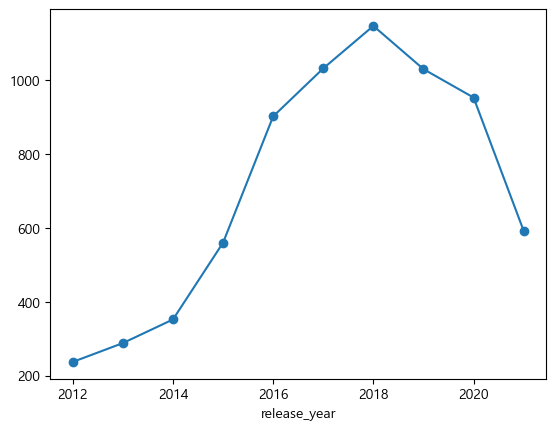

In [38]:
df['release_year'].value_counts().head(10).sort_index().plot(marker='o')
plt.show()

## 조건 필터링

조건을 만족하는 데이터만 선택할 수 있다.


문제: South Korea 제작 컨텐츠만 선택

In [40]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [42]:
df['country'].value_counts().head(20)

country
United States                    2818
India                             972
missing                           831
United Kingdom                    419
Japan                             245
South Korea                       199
Canada                            181
Spain                             145
France                            124
Mexico                            110
Egypt                             106
Turkey                            105
Nigeria                            95
Australia                          87
Taiwan                             81
Indonesia                          79
Brazil                             77
Philippines                        75
United Kingdom, United States      75
United States, Canada              73
Name: count, dtype: int64

In [43]:
df['country'] == 'South Korea'

0       False
1       False
2       False
3       False
4       False
        ...  
8802    False
8803    False
8804    False
8805    False
8806    False
Name: country, Length: 8807, dtype: bool

In [45]:
df_korea = df[df['country'] == 'South Korea']
df_korea

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
104,s105,TV Show,Tayo the Little Bus,missing,"Robyn Slade, Kami Desilets",South Korea,"September 6, 2021",2016,TV-Y,2 Seasons,"Kids' TV, Korean TV Shows",As they learn their routes around the busy cit...
124,s125,TV Show,Pororo - The Little Penguin,missing,missing,South Korea,"September 2, 2021",2013,TV-Y7,3 Seasons,"Kids' TV, Korean TV Shows","On a tiny island, Pororo the penguin has fun a..."
289,s290,TV Show,The Crowned Clown,missing,"Yeo Jin-goo, Lee Se-young, Kim Sang-kyung, Jun...",South Korea,"August 10, 2021",2019,TV-14,1 Season,"International TV Shows, Romantic TV Shows, TV ...","Standing in for an unhinged Joseon king, a loo..."
456,s457,TV Show,Her Private Life,missing,"Park Min-young, Kim Jae-uk, Ahn Bo-hyun, Jung ...",South Korea,"July 15, 2021",2019,TV-14,1 Season,"International TV Shows, Romantic TV Shows, TV ...","An art curator's life unravels, as she tries t..."
545,s546,TV Show,YooHoo to the Rescue,missing,"Kira Buckland, Ryan Bartley, Bryce Papenbrook,...",South Korea,"July 6, 2021",2020,TV-Y,3 Seasons,"Kids' TV, Korean TV Shows","In a series of magical missions, quick-witted ..."
...,...,...,...,...,...,...,...,...,...,...,...,...
8463,s8464,Movie,The President's Barber,Chan-sang Lim,"Kang-ho Song, So-ri Moon, Jae-eung Lee, Yeong-...",South Korea,"October 1, 2017",2004,TV-MA,116 min,"Comedies, Dramas, International Movies","The personal barber to the president, as well ..."
8467,s8468,Movie,The Prison,Na Hyeon,"Suk-kyu Han, Rae-won Kim, Kyeong-yeong Lee, Wo...",South Korea,"November 18, 2017",2017,TV-MA,125 min,"Action & Adventure, Dramas, International Movies",A cop-turned-convict discovers a crime syndica...
8575,s8576,TV Show,This Is My Love,missing,"Jin-mo Joo, Sa-rang Kim, Junior, Ja-in Lee, Su...",South Korea,"May 22, 2017",2015,TV-14,1 Season,"International TV Shows, Korean TV Shows, Roman...",A renowned actor who is still pining over the ...
8613,s8614,Movie,Train to Busan,Sang-ho Yeon,"Gong Yoo, Yu-mi Jung, Dong-seok Ma, Soo-an Kim...",South Korea,"March 18, 2017",2016,TV-MA,118 min,"Action & Adventure, Horror Movies, Internation...","As a zombie outbreak sweeps the country, a dad..."


In [46]:
df_korea[['title', 'release_year']]

,title,release_year
104,Tayo the Little Bus,2016
124,Pororo - The Little Penguin,2013
289,The Crowned Clown,2019
456,Her Private Life,2019
545,YooHoo to the Rescue,2020
...,...,...
8463,The President's Barber,2004
8467,The Prison,2017
8575,This Is My Love,2015
8613,Train to Busan,2016


In [49]:
df_korea.sort_values('release_year', ascending=False)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1210,s1211,TV Show,Love Alarm,missing,"Kim So-hyun, Jung Ga-ram, Song Kang, Ko Min-si...",South Korea,"March 12, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Korean TV Shows, Roman...",In a world where an app alerts people if someo...
902,s903,TV Show,Mine,missing,"Lee Bo-young, Kim Seo-hyung, Lee Hyun-wook, Ok...",South Korea,"May 9, 2021",2021,TV-14,1 Season,"International TV Shows, TV Dramas",Encaged in a gold-clad life of secrets and lie...
1174,s1175,TV Show,Navillera,missing,"Park In-hwan, Song Kang, Na Moon-hee, Hong Seu...",South Korea,"March 23, 2021",2021,TV-14,1 Season,"International TV Shows, TV Dramas",A 70-year-old with a dream and a 23-year-old w...
1173,s1174,TV Show,Men on a Mission,Jung-ah Im,"Ho-dong Kang, Soo-geun Lee, Sang-min Lee, Youn...",South Korea,"March 23, 2021",2021,TV-14,6 Seasons,"International TV Shows, Korean TV Shows, Stand...",Male celebs play make-believe as high schooler...
1298,s1299,TV Show,Sisyphus,missing,"Cho Seung-woo, Park Shin-hye, Sung Dong-il, Ta...",South Korea,"February 18, 2021",2021,TV-14,1 Season,"International TV Shows, TV Action & Adventure,...",An unfathomable incident introduces a genius e...
...,...,...,...,...,...,...,...,...,...,...,...,...
5510,s5511,TV Show,President,missing,"Su-jong Choi, Hee-Ra Ha, Jay Kim, Ji-hye Wang,...",South Korea,"April 28, 2017",2010,TV-14,1 Season,"International TV Shows, Korean TV Shows, TV Dr...","An ambitious, talented politician embarks on a..."
6401,s6402,TV Show,Cain and Abel,missing,"So Ji-sub, Shin Hyun-joon, Chae Jung-an, Han J...",South Korea,"March 12, 2019",2009,TV-MA,1 Season,"International TV Shows, Korean TV Shows, Roman...",Gifted doctor Cho-in leads a charmed life whil...
2518,s2519,TV Show,Iris,missing,"Lee Byung-hun, Kim Tae-hee, Jeong Jun-ho, Kim ...",South Korea,"May 16, 2020",2009,TV-14,1 Season,"International TV Shows, Korean TV Shows, TV Ac...",Two friends' lives are changed forever when th...
2517,s2518,TV Show,Boys Over Flowers,missing,"Ku Hye-sun, Lee Min-ho, Kim Hyun-joong, Kim Bu...",South Korea,"May 16, 2020",2009,TV-14,1 Season,"International TV Shows, Korean TV Shows, Roman...",Unassuming high school girl Jan-di stands up t...


문제1: 한국 컨텐츠 중 영화만 선택 후 최신 순으로(release_year) 정렬

In [52]:
df_korea[df_korea['type'] == 'Movie'].sort_values('release_year', ascending=False)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
556,s557,Movie,The 8th Night,Kim Tae-hyung,"Lee Sung-min, Park Hae-joon, Kim You-jung, Nam...",South Korea,"July 2, 2021",2021,TV-14,116 min,"Horror Movies, International Movies, Thrillers",With prayer beads in one hand and an ax in the...
1085,s1086,Movie,Night in Paradise,Park Hoon-jung,"Um Tae-goo, Jeon Yeo-been, Cha Seoung-won, Lee...",South Korea,"April 9, 2021",2021,TV-MA,132 min,"Dramas, International Movies",Hiding out in Jeju Island following a brutal t...
1342,s1343,Movie,Space Sweepers,Jo Sung-hee,"Song Joong-ki, Kim Tae-ri, Jin Sun-kyu, Yoo Ha...",South Korea,"February 5, 2021",2021,TV-MA,138 min,"Action & Adventure, Dramas, International Movies",Chasing after space debris and faraway dreams ...
1412,s1413,Movie,Wish You,Sung Do-jun,"Kang In-soo, Lee Sang, Soo-bin",South Korea,"January 15, 2021",2021,TV-PG,102 min,"Dramas, International Movies, LGBTQ Movies","Singing and dreaming together, a talented sing..."
1468,s1469,Movie,What Happened to Mr. Cha?,Kim Dong-kyu,"Cha In-pyo, Cho Dal-hwan, Song Jae-ryong",South Korea,"January 1, 2021",2021,TV-MA,102 min,"Comedies, International Movies","With the peak of his career long behind him, a..."
762,s763,Movie,Sweet & Sour,Lee Kae-byeok,"Jang Ki-yong, Chae Soo-bin, Jung Soo-jung",South Korea,"June 4, 2021",2021,TV-14,103 min,"Comedies, International Movies, Romantic Movies",Faced with real-world opportunities and challe...
1643,s1644,Movie,The Call,Lee Chung-hyun,"Park Shin-hye, Jun Jong-seo, Kim Sung-ryoung, ...",South Korea,"November 27, 2020",2020,TV-MA,112 min,"International Movies, Thrillers",Connected by phone in the same home but 20 yea...
2036,s2037,Movie,#Alive,Cho Il,"Yoo Ah-in, Park Shin-hye",South Korea,"September 8, 2020",2020,TV-MA,99 min,"Horror Movies, International Movies, Thrillers","As a grisly virus rampages a city, a lone man ..."
2215,s2216,Movie,The Larva Island Movie,Ahn Byoung-wook,"Hong Bum-ki, Eddy Lee, Kang Shi-hyun, Ahn Hyo-...",South Korea,"July 23, 2020",2020,TV-Y7,91 min,"Children & Family Movies, Comedies","In this movie sequel to the hit series, Chuck ..."
2650,s2651,Movie,Time to Hunt,Yoon Sung-hyun,"Lee Je-hoon, Ahn Jae-hong, Choi Woo-shik, Park...",South Korea,"April 23, 2020",2020,TV-MA,135 min,"International Movies, Thrillers",Wanting to leave their dystopian world behind ...


문제2: 한국 컨텐츠에서 'Lee Byung-hun' 이 출연한 작품?

df_korea['cast'].str.contains('Lee Byung-hun') 

In [53]:
df_korea['cast'].str.contains('Lee Byung-hun')

104     False
124     False
289     False
456     False
545     False
        ...  
8463    False
8467    False
8575    False
8613    False
8684    False
Name: cast, Length: 199, dtype: bool

In [54]:
df_korea[df_korea['cast'].str.contains('Lee Byung-hun')]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
2518,s2519,TV Show,Iris,missing,"Lee Byung-hun, Kim Tae-hee, Jeong Jun-ho, Kim ...",South Korea,"May 16, 2020",2009,TV-14,1 Season,"International TV Shows, Korean TV Shows, TV Ac...",Two friends' lives are changed forever when th...
4779,s4780,TV Show,Mr. Sunshine,Lee Eung-bok,"Lee Byung-hun, Kim Tae-ri, Yoo Yeon-seok, Kim ...",South Korea,"July 8, 2018",2018,TV-MA,1 Season,"International TV Shows, Korean TV Shows, Roman...",A young boy who ends up in the U.S. after the ...


문제3: 한국 컨텐츠는 어떠한 등급(rating) 이 많은지 등급별 컨텐츠 수 검색

<Axes: xlabel='rating'>

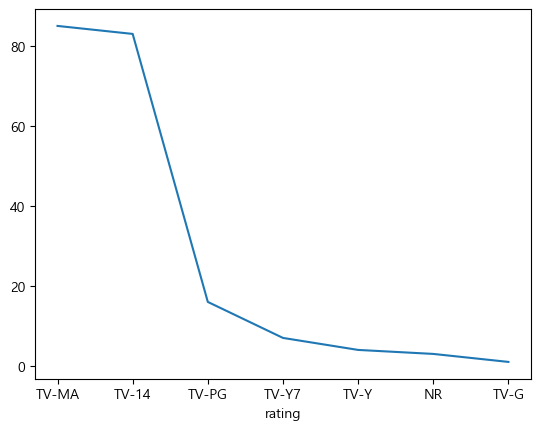

In [57]:
df_korea['rating'].value_counts().plot()

## groupby()를 이용한 그룹 분석


### `df.groupby('기준열')['집계열'].집계함수()`  
기준열 값이 같은 것끼리 **그룹을 나눈 뒤**, 각 그룹에 대해 **집계열의 통계값**을 계산
#### 자주 쓰는 집계 함수
| 함수 | 의미 |
|------|------|
| `.count()` | 행 수 세기 |
| `.mean()` | 평균 |
| `.sum()` | 합계 |
| `.min()` / `.max()` | 최소값 / 최대값 |
| `.size()` | 그룹 크기 |

문제 1: 컨텐츠 유형(type)별 가장 오래된 출시 연도

In [58]:
df.groupby('type')['release_year'].min()

type
Movie      1942
TV Show    1925
Name: release_year, dtype: int64

문제 2: 컨텐츠 유형(type)별 가장 최근 출시 연도

In [59]:
df.groupby('type')['release_year'].max()

type
Movie      2021
TV Show    2021
Name: release_year, dtype: int64

문제 3: 연도(release_year)별 컨텐츠 수

In [60]:
df.groupby('release_year')['title'].count().sort_values(ascending=False).head(10)

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
2021     592
2015     560
2014     352
2013     288
2012     237
Name: title, dtype: int64

In [62]:
df['release_year'].value_counts().head(10)

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
2021     592
2015     560
2014     352
2013     288
2012     237
Name: count, dtype: int64

In [63]:
df.groupby('release_year').size().sort_values(ascending=False).head(10)

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
2021     592
2015     560
2014     352
2013     288
2012     237
dtype: int64

In [ ]:
문제 4: 연도(release_year)와 유형(type)의 그룹별 컨텐츠 수

In [65]:
df.groupby(['release_year' ,'type']).size().unstack()

type,Movie,TV Show
release_year,,
1925,NaN,1.0
1942,2.0,NaN
1943,3.0,NaN
1944,3.0,NaN
1945,3.0,1.0
...,...,...
2017,767.0,265.0
2018,767.0,380.0
2019,633.0,397.0


<Axes: xlabel='release_year'>

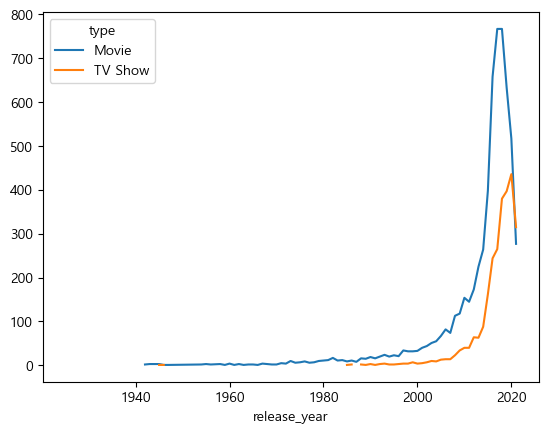

In [66]:
df.groupby([ 'release_year' ,'type']).size().unstack().plot()

In [67]:
pd.set_option('display.max_rows', None)

In [68]:
pd.set_option('display.max_columns', None)

In [69]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [70]:
df['description']

0       As her father nears the end of his life, filmm...
1       After crossing paths at a party, a Cape Town t...
2       To protect his family from a powerful drug lor...
3       Feuds, flirtations and toilet talk go down amo...
4       In a city of coaching centers known to train I...
5       The arrival of a charismatic young priest brin...
6       Equestria's divided. But a bright-eyed hero be...
7       On a photo shoot in Ghana, an American model s...
8       A talented batch of amateur bakers face off in...
9       A woman adjusting to life after a loss contend...
10      Sicily boasts a bold "Anti-Mafia" coalition. B...
11      Struggling to earn a living in Bangkok, a man ...
12      After most of her family is murdered in a terr...
13      When the clever but socially-awkward Tetê join...
14      Cameras following Bengaluru police on the job ...
15      Students of color navigate the daily slights a...
16      Declassified documents reveal the post-WWII li...
17      Strang

In [71]:
pd.set_option('display.max_colwidth', None)

In [72]:
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
pd.reset_option('display.max_colwidth')

!pip install wordcloud

In [73]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


#### from wordcloud import WordCloud
-  wordcloud 라이브러리에서 WordCloud 클래스를 가져오기
#### wc = WordCloud ()
-  WordCloud 객체 wc 생성

from wordcloud import WordCloud

In [74]:
from wordcloud import WordCloud

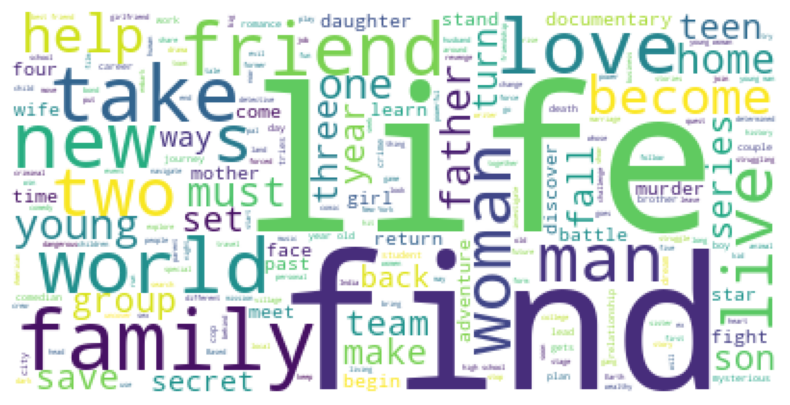

In [77]:
text =' '.join(df['description'])
wc = WordCloud (background_color='white').generate(text)
plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis('off')
plt.show()

## 과제 다음 질문에 한글로 답을적어보세요

1. Netflix에서는 `Movie`와 `TV Show` 중 어떤 유형이 더 많은가?  

In [78]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [ ]:
Movie 유형

2. 컨텐츠 수가 많은 국가는 상위 3개국은 어디인가?  

In [80]:
df['country'].value_counts().head(5)

country
United States     2818
India              972
missing            831
United Kingdom     419
Japan              245
Name: count, dtype: int64

In [ ]:
미국, 인도, 영국

3. 결측값이 가장 많은 컬럼은?

In [84]:
(df == 'missing').sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [ ]:
director가 가장 많다

## 이번 주 수업에서 알게 된 것, 어려웠던 것, 교수에게 전할 말 등 적어주세요

In [ ]:
3번 문제를 풀 때 df.isnull().sum()을 실행했는데 모든 값이 0으로 나와서 좀 당황했지만,

In [ ]:
알고 보니 실습하면서 df.fillna('missing')를 통해 결측치를 이미 처리했기 때문이라는 것을 알게 되었습니다. 

In [ ]:
전처리의 순서가 분석 결과에 얼마나 큰 영향을 주는지 알게 되었습니다.